# Поиска инсайтов и точек роста для сервиса доставки еды

### Цели проекта

Помочь бизнесу ответить на следующие вопросы:
- Как ведут себя пользователи? Как наиболее эффективно выстроить работу с ними, чтобы они продолжали пользоваться продуктом?
- Какой путь проходят пользователи в сервисе? Где «проваливаются»?
- Как улучшить взаимодействие с партнёрами-ресторанами?

### Задачи 

В рамках данного проекта необходимо комплексный анализ данных:
- изучить пользовательский путь и проанализировать конверсии через воронки;
- сегментировать пользователей с помощью RFM-модели для оценки лояльности и поведения клиентов;
- кластеризовать рестораны методом K-Means, чтобы выделить группы с разными моделями работы и разработать персонализированные маркетинговые стратегии.



### Данные

Данные включают следующие сведения:
      
- `visitor_uuid` — идентификатор посетителя. Это идентификатор, который присваивается системой любому новому пользователю вне зависимости от того, зарегистрировался он в продукте или нет.
- `user_id` — идентификатор зарегистрированного пользователя. Присваивается посетителю после создания учётной записи: ввода логина, пароля, адреса доставки и контактных данных.
- `device_type` — тип платформы, с которой посетитель зашёл в продукт.
- `city_id` — город, из которого посетитель зашёл в сервис.
- `source` — рекламный источник привлечения посетителя.
- `first_date` — дата первого посещения продукта.
- `visit_id` — уникальный идентификатор сессии.
- `event` — название аналитического события.
- `datetime` — дата и время события.
- `rest_id` — уникальный идентификатор ресторана (заполняется для заказов, карточек ресторанов и блюд).
- `object_id` — уникальный идентификатор блюда (заполняется для заказов и карточек блюд).
- `order_id` — уникальный идентификатор заказа.
- `revenue` — выручка от заказа (в рублях). Это та сумма, которую пользователь видит при оплате.
- `delivery` — стоимость доставки (в рублях).
- `commission` — комиссия, которую «Всё.из.кафе» берёт с выручки ресторана, в процентах.

    
### План проекта
- Загрузка данных и их предобработка.
- Анализ пользовательского пути новых пользователей.
- RFM сегментация.
- K-Means кластеризация.
- Итоговый вывод и рекомендации.

## 1. Загрузка данных и их предобработка



In [ ]:
import pandas as pd
!pip install missingno
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


c:\Users\Lenovo\anaconda3\envs\practicum\lib\site-packages\sklearn\utils\fixes.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version  # type: ignore


In [ ]:
df=pd.read_csv('',parse_dates=['first_date','datetime'])

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205510 entries, 0 to 205509
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   visitor_uuid  205510 non-null  object        
 1   user_id       205510 non-null  float64       
 2   device_type   205510 non-null  object        
 3   city_id       205510 non-null  int64         
 4   source        205510 non-null  object        
 5   first_date    205510 non-null  datetime64[ns]
 6   visit_id      205510 non-null  int64         
 7   event         205510 non-null  object        
 8   datetime      205510 non-null  datetime64[ns]
 9   rest_id       166915 non-null  object        
 10  object_id     21308 non-null   float64       
 11  order_id      7008 non-null    float64       
 12  revenue       7008 non-null    float64       
 13  delivery      7008 non-null    float64       
 14  commission    21308 non-null   float64       
dtypes: datetime64[ns]

### Анализ пропусков в данных

<AxesSubplot:>

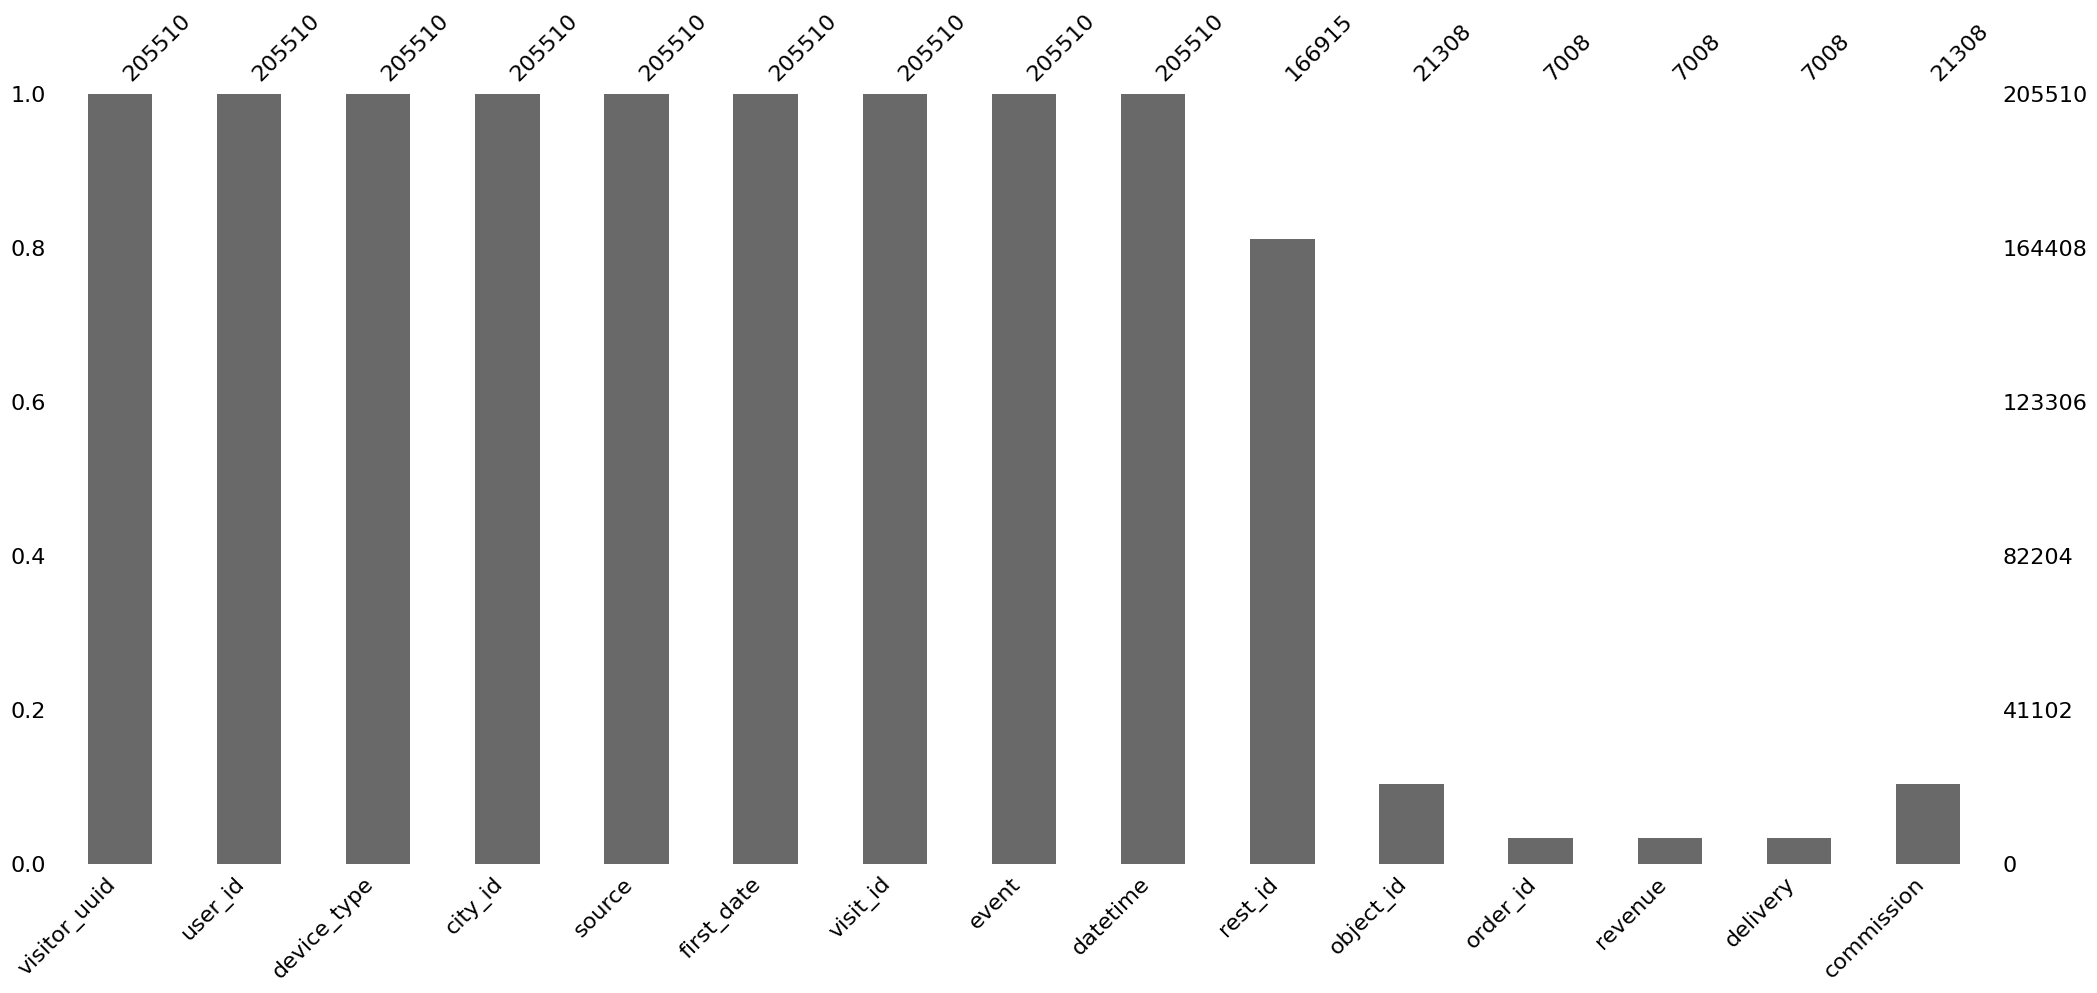

In [5]:
msno.bar(df)

Можно обратить внимание, что количество пропусков в object_id и commission одинаково - 21308, а также в order_id, revenue и delivery - одинаково - 7008. Проверим их взаимосвязь.

<AxesSubplot:>

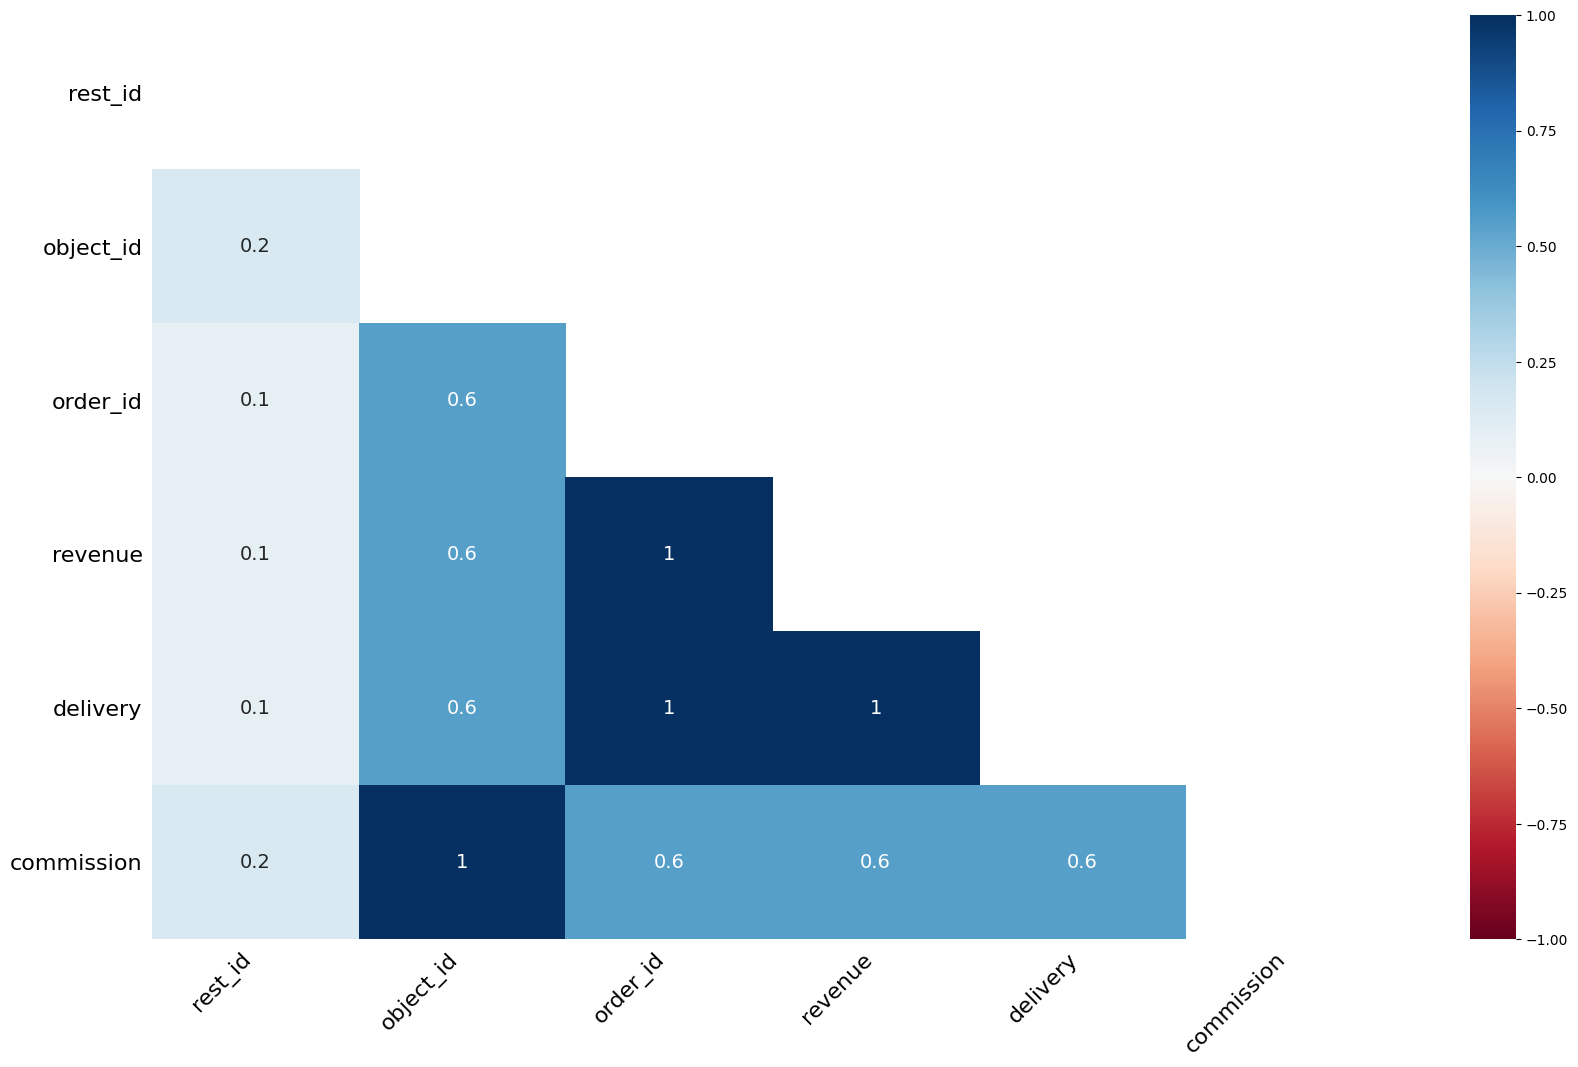

In [6]:
msno.heatmap(df)

Действительно, для строк, где пропущен object_id, отсутствует значение комиссии, а также есть строки, где одновременно отсутствуют значения в столбцах с номером заказа, стоимостью доставки и выручкой, что закономерно. 

In [7]:
df[df['rest_id'].isna()]['event'].unique()

array(['authorization', 'reg_page', 'confirm_phone', 'login'],
      dtype=object)

Пропуски в rest_id соответствуют строкам, не связанным с процессом размещения заказов, а соответствуют событиям регистрации, авторизации, подтверждения телефона и входа в приложение.

In [8]:
df[df['object_id'].isna()]['event'].unique()

array(['authorization', 'reg_page', 'confirm_phone', 'login', 'main_page'],
      dtype=object)

Пропуски в object_id (а следовательно, и commission) и соответствуют строкам, не связанным с процессом размещения заказов.

In [9]:
df[df['order_id'].isna()]['event'].unique()

array(['authorization', 'reg_page', 'confirm_phone', 'login', 'main_page',
       'object_page', 'add_to_cart'], dtype=object)

Пропуски в order_id (а следовательно, и revenue, delivery) соответствуют строкам, не связанным с размещенными заказами.

### Анализ дубликатов 

In [10]:
df.duplicated().sum()

0

Явные дубликаты в датасете отсутствуют.

In [11]:
categorial_columns=['device_type','source','event']
for i in categorial_columns:
    print(df[i].unique())

['Desktop' 'Mobile']
['Source_B' 'organic' 'Source_A' 'Source_C']
['authorization' 'reg_page' 'confirm_phone' 'login' 'main_page'
 'object_page' 'add_to_cart' 'order']


В категориальных столбцах неявные дубликаты отсутствуют. Датасет готов к последующему анализу.

Дополнительно проверим данные на неявные дубликаты по полям `'user_id','datetime','event'`.

In [12]:
df[df.duplicated(['user_id','datetime','event'],keep=False)]

,visitor_uuid,user_id,device_type,city_id,source,first_date,visit_id,event,datetime,rest_id,object_id,order_id,revenue,delivery,commission
6053,011d6385-8508-44f6-a208-693439a959d2,570334.0,Desktop,6,Source_C,2021-05-01,172092821,authorization,2021-05-03 18:18:38,NaN,NaN,NaN,NaN,NaN,NaN
6054,011d6385-8508-44f6-a208-693439a959d2,570334.0,Desktop,6,Source_C,2021-05-01,172092822,authorization,2021-05-03 18:18:38,NaN,NaN,NaN,NaN,NaN,NaN
14373,f15a5b75-db5b-4329-a82d-31332bb4b62b,570841.0,Desktop,6,organic,2021-05-03,172287156,authorization,2021-05-04 11:47:25,NaN,NaN,NaN,NaN,NaN,NaN
14374,f15a5b75-db5b-4329-a82d-31332bb4b62b,570841.0,Desktop,6,organic,2021-05-03,172287157,authorization,2021-05-04 11:47:25,NaN,NaN,NaN,NaN,NaN,NaN
33611,34368fa2-ecc3-4285-8ba5-2cede61d9b2e,580940.0,Desktop,6,Source_B,2021-05-11,174457841,authorization,2021-05-12 13:06:43,NaN,NaN,NaN,NaN,NaN,NaN
33612,34368fa2-ecc3-4285-8ba5-2cede61d9b2e,580940.0,Desktop,6,Source_B,2021-05-11,174457842,authorization,2021-05-12 13:06:43,NaN,NaN,NaN,NaN,NaN,NaN
37420,70eef638-0f3e-434e-b223-b432ee0f4771,146532.0,Desktop,6,Source_C,2021-05-12,174642056,authorization,2021-05-13 10:09:20,NaN,NaN,NaN,NaN,NaN,NaN
37421,70eef638-0f3e-434e-b223-b432ee0f4771,146532.0,Desktop,6,Source_C,2021-05-12,174642057,authorization,2021-05-13 10:09:20,NaN,NaN,NaN,NaN,NaN,NaN
44234,3473a33f-381c-42cc-902b-65f3178f30d8,563661.0,Desktop,6,Source_C,2021-05-16,176217598,authorization,2021-05-18 08:47:52,NaN,NaN,NaN,NaN,NaN,NaN
44566,3473a33f-381c-42cc-902b-65f3178f30d8,563661.0,Desktop,6,Source_C,2021-05-16,176217599,authorization,2021-05-18 08:47:52,NaN,NaN,NaN,NaN,NaN,NaN


Найдено 7 дублированных строк, в которых совпадают все столбцы, кроме id посещения. Их необходимо удалить.

In [13]:
df=df.drop_duplicates(subset=['user_id','datetime','event']).reset_index()

В рамках ознакомления с датасетом рассчитаем количество уникальных пользователей, ресторанов, а также период, за который представлены данные. 

In [14]:
df['user_id'].nunique()

8473

In [15]:
df['rest_id'].nunique()

21

In [16]:
df['datetime'].describe()

count                           205503
mean     2021-06-01 05:25:28.537738752
min                2021-05-01 00:10:55
25%         2021-05-19 17:05:30.500000
50%                2021-06-02 15:14:06
75%         2021-06-13 20:40:10.500000
max                2021-07-02 00:12:08
Name: datetime, dtype: object

Данные представлены за 2 месяца - с 1 мая 2021 года по 2 июля 2021 года, количество уникальных пользователей - 8473, количество ресторанов - 21. 

---

## 2. Анализ пользовательского пути


Построим и визуализируем общую воронку, опишем пользовательский путь: какие этапы представлены, какова их последовательность, на каких этапах теряется большая часть новых пользователей.
    
Предполагается, что пользователь проходит такой путь к оформлению доставки блюда из ресторанов:
1. `authorization` — авторизация пользователя — запуск приложения.
2. `main_page` — загрузка основной страницы приложения.
2. `reg_page` — переход на страницу регистрации.
2. `confirm_phone` — подтверждение телефона (окончание процесса регистрации).
2. `object_page` — страница блюда.
2. `add_to_cart` — переход в корзину.
2. `order` — оформление заказа.    

In [17]:
steps=['authorization','main_page','reg_page','confirm_phone','object_page','add_to_cart','order']
users_qty=[]

In [18]:
users_qty = [df[df['event'] == i]['user_id'].nunique() for i in steps]
funnel = pd.DataFrame({'step': steps, 'users_qty': users_qty})

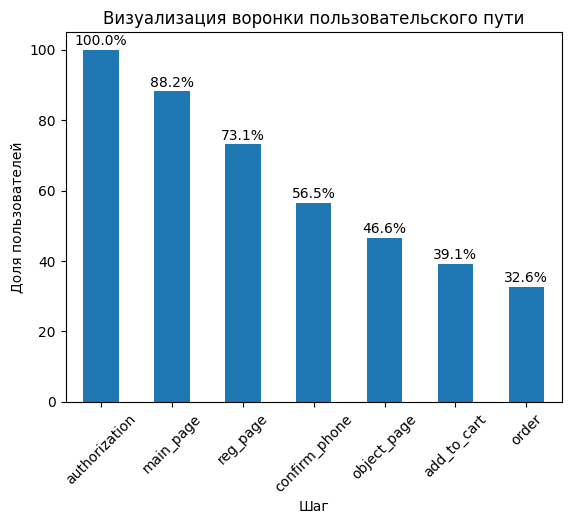

In [24]:
funnel['share']=round(funnel['users_qty']/funnel['users_qty'].max()*100,2)
ax =funnel.plot(kind='bar',x='step',y='share',
            rot=45,
            title='Визуализация воронки пользовательского пути',
            xlabel='Шаг',
            ylabel='Доля пользователей', 
            legend=False)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom')



In [25]:
funnel

,step,users_qty,share
0,authorization,7410,100.00
1,main_page,6537,88.22
2,reg_page,5417,73.10
3,confirm_phone,4190,56.55
4,object_page,3453,46.60
5,add_to_cart,2899,39.12
6,order,2416,32.60


На первый взгляд, на каждом этапе воронки происходит плавное снижение доли пользователей. Падение наблюдается с самого начала пользовательского пути - 12% теряются уже на первом шаге - загрузки основной страницы. Возможно, загрузка идет с ошибкой (приложение "вылетает" или сайт не открывается). На каждом шаге теряется от 10% до 18% от общего количества пользователей. Конверсия в заказ составляет 32,6%. 

In [27]:
funnel['step_by_step']=funnel['users_qty']/funnel['users_qty'].shift(1)*100
funnel

,step,users_qty,share,step_by_step
0,authorization,7410,100.00,NaN
1,main_page,6537,88.22,88.218623
2,reg_page,5417,73.10,82.866758
3,confirm_phone,4190,56.55,77.349086
4,object_page,3453,46.60,82.410501
5,add_to_cart,2899,39.12,83.955980
6,order,2416,32.60,83.339082


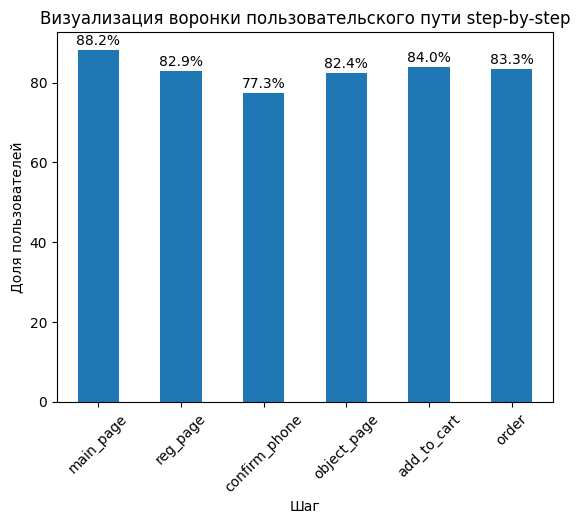

In [28]:
ax=funnel.iloc[1:].plot(kind='bar',x='step',y='step_by_step',
            rot=45,
            title='Визуализация воронки пользовательского пути step-by-step',
            xlabel='Шаг',
            ylabel='Доля пользователей', 
            legend=False)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom')

Самая большая доля потерянных пользователей происходит с шага "страница регистрации" на шаг "подтверждение телефона". Возможно, процесс подтверждения телефона неудобен или происходит с ошибкой, из-за чего почти 23% не приходят на следующий шаг. Также нехорошо выглядит существенное совокупное падение на первых 3 шагах - с входа в приложения до подтверждение телефона - до 56.55% от общего числа привлеченных пользователей. 

In [29]:
mobile_df = df[df['device_type'] == 'Mobile']
desktop_df = df[df['device_type'] == 'Desktop']

In [30]:
mobile_count=mobile_df.groupby('event')['user_id'].nunique().reindex(steps)
desktop_count=desktop_df.groupby('event')['user_id'].nunique().reindex(steps)
mobile_funnel = (mobile_count/mobile_count.shift(1)*100).round(2)
desktop_funnel=(desktop_count/desktop_count.shift(1)*100).round(2)

In [31]:
funnel_compare = pd.DataFrame({
   'step': steps[1:],
   'mobile_classic':(mobile_count[1:]/mobile_count[0]*100).round(2),
   'desktop_classic':(desktop_count[1:]/desktop_count[0]*100).round(2),
   'mobile_step_by_step' : mobile_funnel[1:],
   'desktop_step_by_step': desktop_funnel[1:]
}).reset_index(drop=True)
funnel_compare

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3372\3058615498.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'mobile_classic':(mobile_count[1:]/mobile_count[0]*100).round(2),
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3372\3058615498.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'desktop_classic':(desktop_count[1:]/desktop_count[0]*100).round(2),


,step,mobile_classic,desktop_classic,mobile_step_by_step,desktop_step_by_step
0,main_page,83.31,91.05,83.31,91.05
1,reg_page,73.63,72.25,88.38,79.35
2,confirm_phone,40.53,65.20,55.05,90.24
3,object_page,29.40,55.94,72.52,85.79
4,add_to_cart,25.48,46.38,86.68,82.91
5,order,21.85,38.19,85.75,82.34


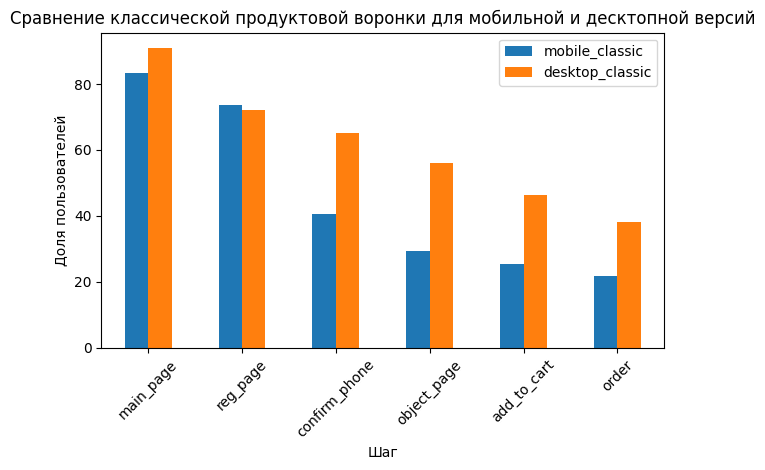

In [32]:
funnel_compare[['step','mobile_classic','desktop_classic']].plot(kind='bar',x='step',rot=45, 
                    xlabel='Шаг',
                    ylabel='Доля пользователей',
                    title='Сравнение классической продуктовой воронки для мобильной и десктопной версий',
                    legend=True
                    )
plt.legend(loc='best') 
plt.tight_layout()
plt.show()

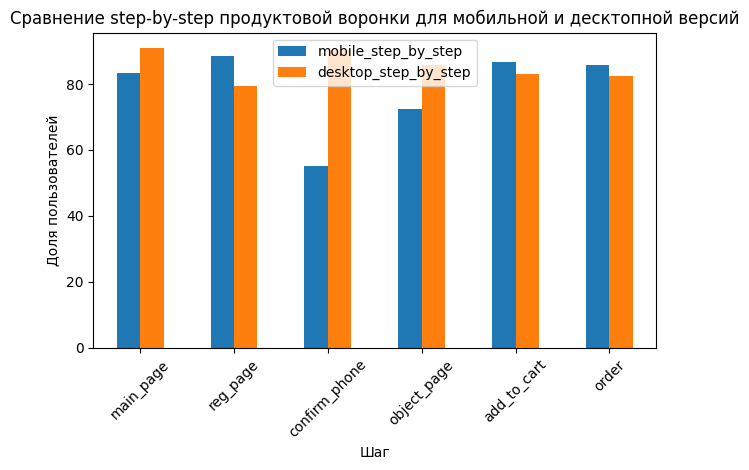

In [33]:
funnel_compare[['step','mobile_step_by_step','desktop_step_by_step']].plot(kind='bar',x='step',rot=45, 
                    xlabel='Шаг',
                    ylabel='Доля пользователей',
                    title='Сравнение step-by-step продуктовой воронки для мобильной и десктопной версий',
                    legend=True
                    )
plt.legend(loc='best') 
plt.tight_layout()
plt.show()

#### Промежуточный вывод

- На визуализации видно, что на мобильной версии 45% (!) пользователей теряется на этапе подтверждения телефона - возможно, есть проблема с интерфейсом или сбои на этом этапе работы приложения. 
- В то же время для десктопной версии потери пользователей на этом этапе составляет всего 10%. 
- Также в мобильной версии 17% пользователей не доходят даже на 1 шаг - просмотр главной страницы приложения. Возможно, есть глобальные проблемы в работе приложения или привлекается некачественный трафик (для них приложение оказывается неинтересным и после открытия они не взаимодействуют с ним). 
- В десктопной версии больше пользователей (20%), чем в мобильной (12%), не завершают шаг регистрации. Возможно, форма регистрации в десктопной версии оказывается для пользователей менее удобной или содержит больше обязательных полей. 


---

## 3. RFM сегментация

У сервиса доставки еды не такое высокое удержание пользователей: в первый день возвращается около 14% посетителей, а на седьмой день и того меньше — около 4–5%. Маркетологи хотят запустить несколько рекламных кампаний, направленных на удержание платящих пользователей и их возврат в сервис, если они давно не совершали заказы.

Для этого необходимо сегментировать пользователей на различные поведенческие сегменты с помощью RFM-сегментации по трём показателям: 
- **давность** (Recency), 
- **частота покупок** (Frequency), 
- **сумма трат** (Monetary).

Для каждого покупателя необходимо посчитать:
- количество дней с последней покупки — давность (R);
- частоту покупок (F);
- стоимость всех покупок — сумму трат (M).
    


In [34]:
#Дней с последней покупки
df['recency'] = (pd.to_datetime('2021-07-03') - 
                 df[df['event'] == 'order'].groupby('user_id')['datetime'].transform('max')).dt.days

Проверим на возможные ошибки по выручке - с неположительным или пустым значением.

In [35]:
df[(df['event'] == 'order')&((df['revenue']<=0)|(df['revenue'].isna()))]

,index,visitor_uuid,user_id,device_type,city_id,source,first_date,visit_id,event,datetime,rest_id,object_id,order_id,revenue,delivery,commission,recency


Такие строки в датасете отсутствуют.

In [36]:
df_rfm = df[df['event']=='order'].groupby('user_id').agg(
    # Количество дней с последнего заказа:    
    recency = ('recency', 'min'),
    # Количество заказов за период времени: 
    frequency = ('datetime', 'count'),
    # Сумма стоимости всех заказов: 
    monetary_value = ('revenue', 'sum')
).reset_index()


Text(0, 0.5, 'Количество пользователей')

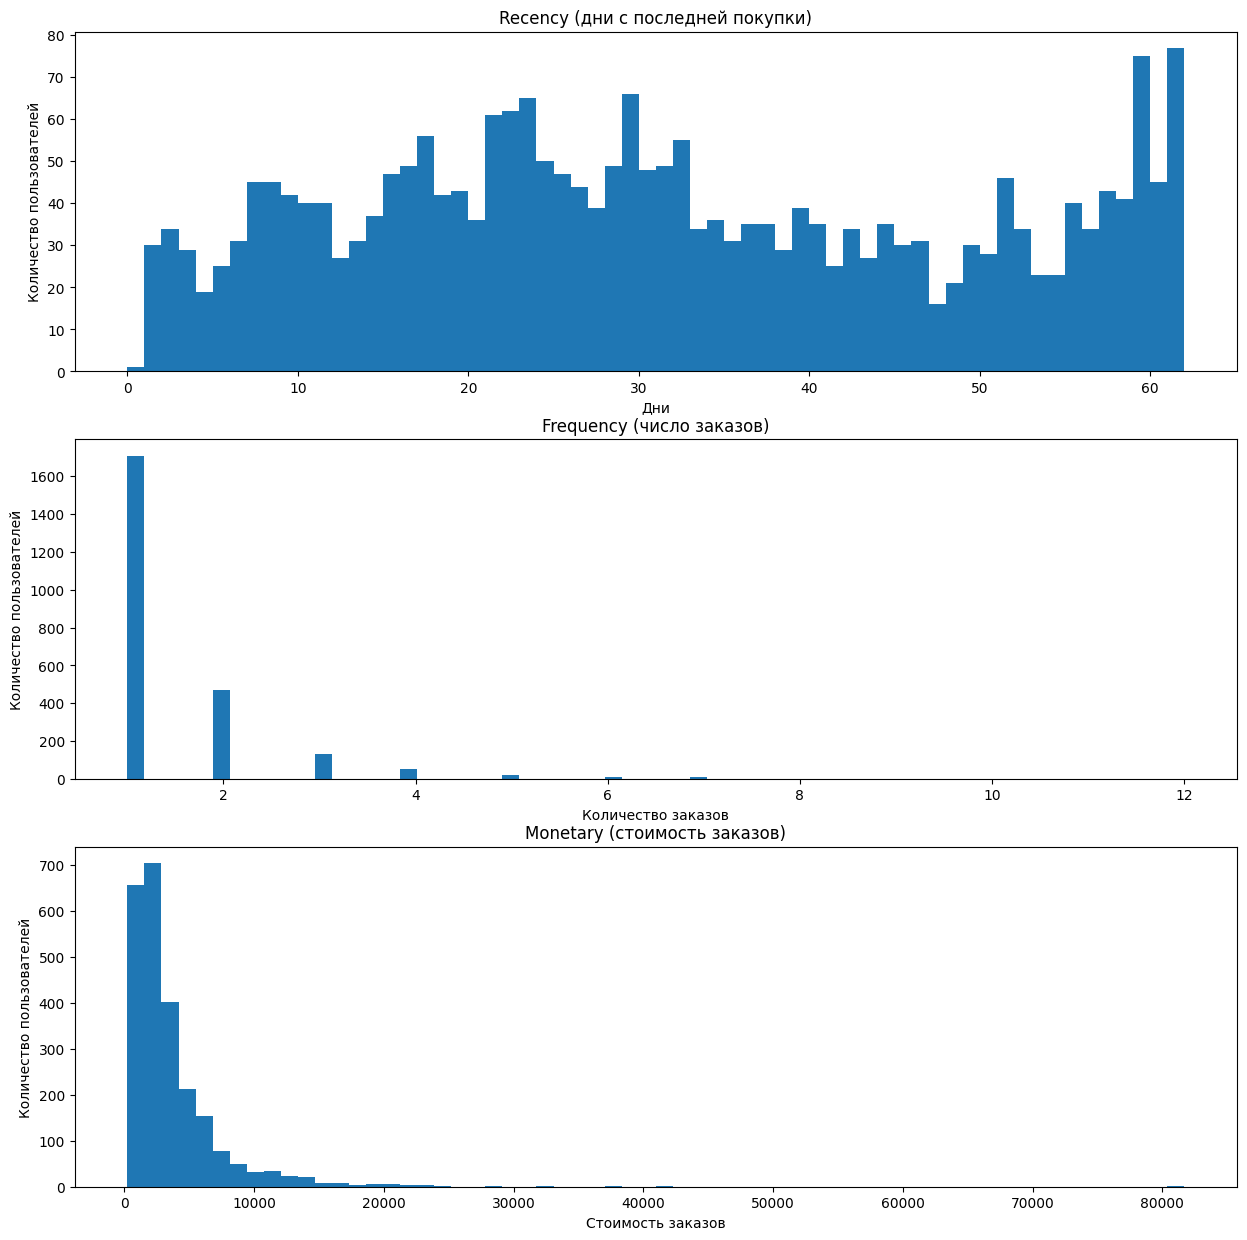

In [37]:
# Строим три гистограммы
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

# Давность
axes[0].hist(df_rfm['recency'], bins=62)
axes[0].set_title('Recency (дни с последней покупки)')
axes[0].set_xlabel('Дни')
axes[0].set_ylabel('Количество пользователей')

# Частота
axes[1].hist(df_rfm['frequency'], bins=62)
axes[1].set_title('Frequency (число заказов)')
axes[1].set_xlabel('Количество заказов')
axes[1].set_ylabel('Количество пользователей')

# Сумма всех заказов
axes[2].hist(df_rfm['monetary_value'], bins=62)
axes[2].set_title('Monetary (стоимость заказов)')
axes[2].set_xlabel('Стоимость заказов')
axes[2].set_ylabel('Количество пользователей')

По давности последнего заказа пользователи распределены достаточно равномерно, большинство из них совершило 1-2 заказа, для подавляющего большинства пользователей суммарная стоимость заказов составляет менее 5000 р.

Выделим RFM сегменты:
- **Recency** — разделим на три равные группы.
- **Frequency** —  разделим на три группы: 
    - пользователи с 1 заказом (F-сегмент с небольшим количеством заказов);
    - пользователи с 2 заказами (F-сегмент со средним количеством заказов);
    - пользователи с 3 и более заказами (F-сегмент с большим количеством заказов).
- **Monetary** — разделим на три группы по 33-му и 66-му перцентилям.
    


In [38]:
df_rfm['r'] = pd.cut(df_rfm['recency'], bins=3, labels=[3,2,1])


In [39]:
df_rfm['f'] = pd.cut(df_rfm['frequency'], [1,2,3,20], labels=[1,2,3],include_lowest=True)

In [40]:
df_rfm['m'] = pd.qcut(df_rfm['monetary_value'], q=3, labels=[1,2,3])


In [41]:
df_rfm[['r','f','m']] = df_rfm[['r','f','m']].astype('str')
df_rfm['rfm_group'] = df_rfm['r'] + df_rfm['f'] + df_rfm['m']
df_rfm

,user_id,recency,frequency,monetary_value,r,f,m,rfm_group
0,5506.0,32.0,2,3752.000,2,1,3,213
1,6291.0,57.0,1,1750.000,1,1,1,111
2,6820.0,41.0,1,1260.140,2,1,1,211
3,11062.0,57.0,1,3785.600,1,1,3,113
4,13254.0,54.0,1,553.000,1,1,1,111
...,...,...,...,...,...,...,...,...
2411,645478.0,1.0,3,3412.528,3,2,2,322
2412,645500.0,1.0,1,2004.800,3,1,2,312
2413,645957.0,1.0,1,3591.784,3,1,2,312
2414,645976.0,1.0,2,1990.800,3,1,2,312


In [42]:
rfm_group = df_rfm.groupby('rfm_group').agg({'user_id':'nunique'}).rename(columns={'user_id':'total_users'}).sort_values(by='total_users',ascending=False).reset_index()
rfm_group['rfm_group_share']=(rfm_group['total_users']/rfm_group['total_users'].sum()*100).round(2)
rfm_group

,rfm_group,total_users,rfm_group_share
0,212,296,12.25
1,211,289,11.96
2,111,263,10.89
3,112,261,10.80
4,311,255,10.55
5,213,237,9.81
6,312,234,9.69
7,313,187,7.74
8,113,160,6.62
9,223,56,2.32


#### Промежуточные выводы и рекомендации

- Самые прибыльные для бизнеса клиенты - из сегмента 333 (таких всего 1,37%), а также немного им уступают 332, 323, 233 (суммарно около 3,40%). Сегмент 133 составляет 0,75% - эти пользователи совершили 3 и более заказов на крупную сумму. Необходимо разработать эксклюзивные предложения для поддержания лояльности пользователей из перечисленных сегментов, а уступающим по одному показателю - поднимать его.
- Сегменты  213 (9,81%), 312 (9,69%), 313 (7,74%) и 113 (6,62%) -  совершили всего один заказ, на крупную или среднюю сумму, их много - почти 34% -, и в них есть потенциал. Важно их не потерять и стимулировать их к повторным заказам.    
- В сегментах 223 (2,32%) и 123 (0,95%) пользователи совершили 2 заказа на крупную сумму, но сделали это достаточно давно - нужно их вернуть. 
- Большую долю составляют сегменты 212 (12,25%), 211 (11,96%), 111 (10,89%), 112 (10,8%), 311 (10,55%) (в сумме около 56,5%!!)  сделали 1 заказ на среднюю или малую сумму, нужно попробовать простимулировать их к повторному заказу с помощью скидки. 
- Доля остальных сегментов составляет менее 1%

---

## 4. K-Means кластеризация

Чтобы лучше понимать поведение ресторанов и предлагать им персонализированные условия сотрудничества, а также создавать персонализированные предложения для пользователей, маркетологи запросили кластеризацию ресторанов по следующим параметрам:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

С помощью метода K-Means разделим рестораны на кластеры, отражающие различные модели работы и целевые сегменты. Это позволяет выделить группы ресторанов с похожими характеристиками и разрабатывать для них эффективные маркетинговые стратегии.

Подготовим данные для кластеризации и для каждого ресторана подсчитаем:
- общее количество заказов;
- средняя стоимость заказа;
- общее число заказанных уникальных блюд (ассортимент ресторана).

In [43]:
df_agg= df[df['event']=='order'].groupby('rest_id').agg({
'order_id':'nunique',
'revenue':'mean',
'object_id':'nunique'}
).rename(columns={'order_id':'order_qty', 'object_id':'dish_qty','revenue':'avg_bill'})
df_agg

,order_qty,avg_bill,dish_qty
rest_id,,,
1be5a933aab34fbab594bebba48e976e,144,2260.180222,28
1d6bb74687104fa1953924c9684fe624,108,2959.256481,19
2c6095730b514c189ee41c65f03febc3,8,1673.000000,4
3247a3b5f9494812a3c1a73c5b61f004,33,2777.209697,4
39b7eab4f4704ed2886fafe171489960,33,2011.269697,5
43e40bacafe8409bb5592877a42d737e,43,3313.064186,6
4a693ca500b44ba499f92a724aec5f17,107,2989.588785,12
4b9cde3378c447ed81c2c6d4854d4f7e,7,2544.000000,5
55d4027ac83e438f9f893892f6903409,1001,2674.652364,75


In [44]:
df_agg.describe()

,order_qty,avg_bill,dish_qty
count,21.000000,21.000000,21.000000
mean,169.000000,2557.595053,15.285714
std,315.844899,900.370846,23.698403
min,5.000000,1507.735289,1.000000
25%,23.000000,1874.545455,4.000000
50%,77.000000,2369.043478,6.000000
75%,135.000000,2959.256481,13.000000
max,1199.000000,4754.400000,91.000000


Нормализуем данные и найдем оптимальное количество кластеров, использовуя метод `.inertia_`.

In [ ]:
df_agg_scaled = StandardScaler().fit_transform(df_agg)

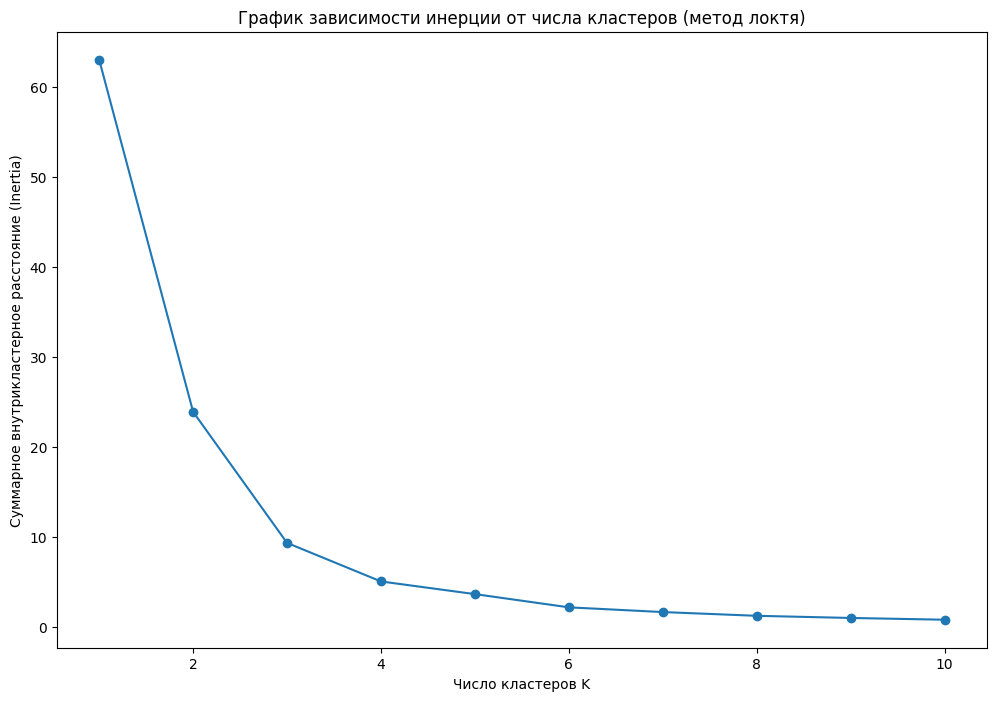

In [46]:
# Создаём массив, в котором будем хранить значения inertia для разбиения с разным числом кластеров
i = []

# Задаём диапазон количества кластеров
min_k = 1
max_k = 10

plt.figure(figsize=(12, 8))

# Перебираем разное количество кластеров
for k in range(min_k, max_k + 1):
   km = KMeans(n_clusters=k)  # Создаём модель KMeans для текущего значения k
   km.fit_transform(df_agg_scaled)  # Обучаем модель и получаем координаты точек в пространстве кластеров
   i.append(km.inertia_)  # Сохраняем значение инерции для текущего k

# Строим график зависимости инерции от количества кластеров
plt.plot(range(min_k, max_k + 1), i, marker='o')
plt.xlabel('Число кластеров K')  # Подпись оси X
plt.ylabel('Суммарное внутрикластерное расстояние (Inertia)')  # Подпись оси Y
plt.title('График зависимости инерции от числа кластеров (метод локтя)')  # Заголовок
plt.show()


Оптимальным количеством кластеров будем считать 5 - после этого значения суммарное внутрикластерное расстояние убывает медленно. 

In [48]:
df_scaled = pd.DataFrame(df_agg_scaled, columns=['order_qty', 'avg_bill','dish_qty'])

Проведем кластеризацию, проанализируем полученные результаты и рассчитаем средние значения по каждому кластеру.


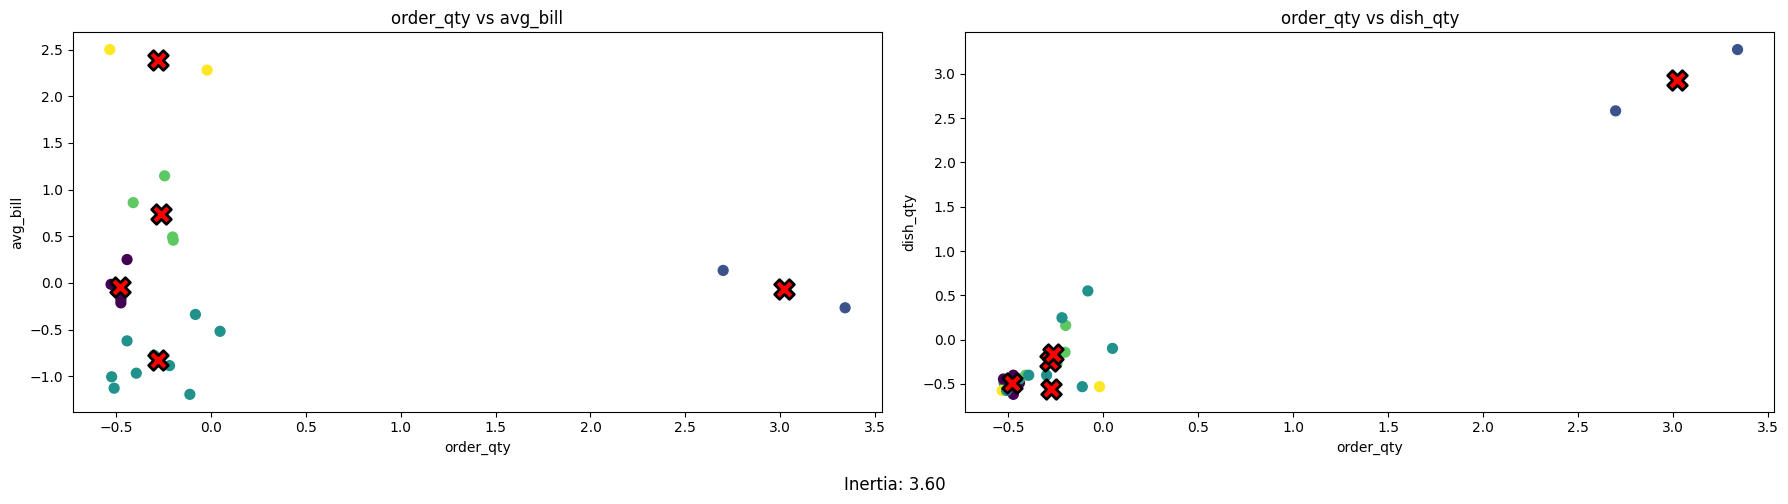

In [49]:
kmeans = KMeans(n_clusters=5,random_state=1)
labels = kmeans.fit_predict(df_scaled)

# Получаем координаты центров (центроидов) кластеров
centroids = kmeans.cluster_centers_

# Создаём 3 графика (1 строка × 2 столбца) для отображения попарных комбинаций признаков
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Список названий признаков, которые будут использоваться на графиках
axs = ["order_qty", "avg_bill", "dish_qty"]

# Перебираем пары признаков:
for i, (x_idx, y_idx) in enumerate([[0,1], [0,2]]):
   x_label, y_label = axs[x_idx], axs[y_idx]  # Названия признаков для осей

   # Строим точки — объекты из датафрейма, раскрашенные по меткам кластера
   axes[i].scatter(
       df_scaled[x_label],  # Значения по оси X
       df_scaled[y_label],  # Значения по оси Y
       c=labels,  # Цвет зависит от номера кластера
       cmap='viridis',  # Цветовая карта
       s=50  # Размер точек
   )

   # Строим центроиды кластеров красными крестами
   axes[i].scatter(
       centroids[:, x_idx],  # X-координаты центров
       centroids[:, y_idx],  # Y-координаты центров
       s=200,  # Размер крестов
       c='red',  # Цвет — красный
       edgecolors='black',  # Обводка — чёрная
       linewidths=2,  # Толщина обводки
       marker='X'  # Форма маркера — крест
   )

   # Подписи осей и заголовок графика
   axes[i].set_xlabel(x_label)
   axes[i].set_ylabel(y_label)
   axes[i].set_title(f'{x_label} vs {y_label}')

# Подгоняем макет, оставляя место снизу для подписи с инерцией
plt.tight_layout(rect=[0, 0.05, 1, 1])

# Добавляем текст с СВР внизу графика (по центру)
fig.text(0.5, 0.01, f'Inertia: {kmeans.inertia_:.2f}', ha='center', fontsize=12)

# Показываем итоговый набор визуализаций
plt.show()


На графиках визуализированы 5 кластеров:



1 - мало заказов, цена заказа средняя, среднее количество заказываемых блюд

2 - много заказов, цена заказа небольшая, много заказываемых блюд

3 - мало заказов, цена заказа высокая, мало заказываемых блюд

4 - мало заказов, цена заказа низкая, среднее количество заказываемых блюд

5 - мало заказов, цена заказа выше среднего, среднее количество заказываемых блюд


In [ ]:
#Выведем для каждого rest_id номер кластера, к которому он относится
df_clusters = df_agg.copy() 
df_clusters['cluster'] = labels+1 
df_clusters.sort_values(by='cluster')

,order_qty,avg_bill,dish_qty,cluster
rest_id,,,,
a59b5279a8674d7a8a16fbf5d92b5551,23,2399.843478,6,1
3247a3b5f9494812a3c1a73c5b61f004,33,2777.209697,4,1
4b9cde3378c447ed81c2c6d4854d4f7e,7,2544.000000,5,1
c91517a6ca264aadae9725e1774d93ca,23,2369.043478,1,1
8d9fb9d5992f400eaf02660973a66adf,1199,2323.005241,91,2
55d4027ac83e438f9f893892f6903409,1001,2674.652364,75,2
1be5a933aab34fbab594bebba48e976e,144,2260.180222,28,3
8c9307a1485d4f8aa48c6746e46540d8,184,2101.293630,13,3
815a6b063cd84005b02b1fc3b48af951,102,1778.322824,21,3


---

## 5. Итоговый вывод и рекомендации


При анализе пользовательского пути была обнаружены следующие проблемы:
- На этапе подтверждения телефона, особенно, у пользователей мобильной версии сервиса - там теряется 45% пользователей против 10% на десктопной. 
- В мобильной версии 17% пользователей не доходят даже на 1 шаг - просмотр главной страницы приложения. Возможно, есть глобальные проблемы в работе приложения или привлекается некачественный трафик.
- В десктопной версии есть зона роста на этапах регистрации, добавлении в корзину и размещения заказа - возможно, следует упростить интерфейс для повышения конверсии. 

Пользователей сервиса можно разделить на следующие группы: 
- 333, 332, 323, 233, 133 - около 5,5% - VIP и премиум клиенты - заказывают на крупные суммы, нужно поддерживать их лояльность, самые ценные клиенты - разработать для них эксклюзивные предложения
- 223, 123 - около 3% - клиенты с потенциалом - совершили 2 заказа на крупную сумму, необходимо их вернуть 
- 213, 312, 313, 113 - почти 34% - клиенты с потенциалом - совершили 1 заказ на среднюю или крупную сумму - необходимо стимулировать их к повторным заказам - напоминания, персональные скидки, бонусы за второй заказ
- 212, 211, 111, 112, 311 - в около 56,5% - массовый сегмент - стимулирование повторных заказов через скидки, бесплатная доставка

Наиболее ценными для платформы являются рестораны Кластера 2 - они обеспечивают основной поток заказов, и Кластера 3 - они привлекают платежеспособную аудиторию. Рестораны Кластеров 1 и 5 имеют потенциал роста при правильной поддержке, а Кластер 4 требует либо обучения и развития, либо замены на более перспективных игроков. 

Ресторанам Кластера 3 рекомендовать расширить/пересмотреть ассортимент - на момент анализа количество заказываемых блюд из ресторанов в данном сегменте - 2-3, нужно сохранить популярные блюда для постоянных клиентов и подробнее изучить остальное меню - возможно, его пересмотр улучшит продажи. 



Внедрение предложенных рекомендаций позволит повысить удержание пользователей, увеличить частоту заказов и оптимизировать работу с ресторанами-партнерами.